In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium


In [3]:
daily_df = pd.read_csv(r"../Weather_&_Climate_Data/Historical temperature, precipitation, and weather events/raw/climate_data/dailyclimate.csv")
daily_df.shape

(883128, 23)

In [ ]:
print("First 5 elements of the original dataset")
daily_df.head(5)

Index(['Unnamed: 0', 'Date', 'District', 'Latitude', 'Longitude', 'Precip',
       'Pressure', 'Humidity_2m', 'RH_2m', 'Temp_2m', 'WetBulbTemp_2m',
       'MaxTemp_2m', 'MinTemp_2m', 'TempRange_2m', 'EarthSkinTemp',
       'WindSpeed_10m', 'MaxWindSpeed_10m', 'MinWindSpeed_10m',
       'WindSpeedRange_10m', 'WindSpeed_50m', 'MaxWindSpeed_50m',
       'MinWindSpeed_50m', 'WindSpeedRange_50m'],
      dtype='object')

In [11]:
print("The columns in the dataset are:")
daily_df.columns

The columns in the dataset are:


Index(['Unnamed: 0', 'Date', 'District', 'Latitude', 'Longitude', 'Precip',
       'Pressure', 'Humidity_2m', 'RH_2m', 'Temp_2m', 'WetBulbTemp_2m',
       'MaxTemp_2m', 'MinTemp_2m', 'TempRange_2m', 'EarthSkinTemp',
       'WindSpeed_10m', 'MaxWindSpeed_10m', 'MinWindSpeed_10m',
       'WindSpeedRange_10m', 'WindSpeed_50m', 'MaxWindSpeed_50m',
       'MinWindSpeed_50m', 'WindSpeedRange_50m'],
      dtype='object')

In [12]:
print("The number of columns in the dataset are:")
len(daily_df.columns)

The number of columns in the dataset are:


23

In [15]:
print("The number of null elements in each column:\n", daily_df.isnull().sum())

The number of null elements in each column:
 Unnamed: 0            0
Date                  0
District              0
Latitude              0
Longitude             0
Precip                0
Pressure              0
Humidity_2m           0
RH_2m                 0
Temp_2m               0
WetBulbTemp_2m        0
MaxTemp_2m            0
MinTemp_2m            0
TempRange_2m          0
EarthSkinTemp         0
WindSpeed_10m         0
MaxWindSpeed_10m      0
MinWindSpeed_10m      0
WindSpeedRange_10m    0
WindSpeed_50m         0
MaxWindSpeed_50m      0
MinWindSpeed_50m      0
WindSpeedRange_50m    0
dtype: int64


In [ ]:
print("Some more info on dataset:")
daily_df.info()
len(daily_df.District.value_counts())### 62 district data of nepal

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 883128 entries, 0 to 883127
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          883128 non-null  int64  
 1   Date                883128 non-null  object 
 2   District            883128 non-null  object 
 3   Latitude            883128 non-null  float64
 4   Longitude           883128 non-null  float64
 5   Precip              883128 non-null  float64
 6   Pressure            883128 non-null  float64
 7   Humidity_2m         883128 non-null  float64
 8   RH_2m               883128 non-null  float64
 9   Temp_2m             883128 non-null  float64
 10  WetBulbTemp_2m      883128 non-null  float64
 11  MaxTemp_2m          883128 non-null  float64
 12  MinTemp_2m          883128 non-null  float64
 13  TempRange_2m        883128 non-null  float64
 14  EarthSkinTemp       883128 non-null  float64
 15  WindSpeed_10m       883128 non-nul

62

In [18]:
print("Statistical discription of the dataset")
daily_df.describe()

Statistical discription of the dataset


,Unnamed: 0,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,...,TempRange_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeedRange_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,WindSpeedRange_50m
count,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,...,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000,883128.000000
mean,441563.500000,27.959677,84.277419,2.433753,82.896390,8.491043,55.657950,15.815832,5.428265,21.856533,...,10.795352,15.539531,2.372512,4.673551,0.666903,4.006641,2.730587,4.643453,0.924084,3.719365
std,254937.238603,0.883261,2.181331,6.160721,10.707984,5.426636,22.877576,9.172463,10.850204,8.848121,...,3.306661,9.924091,0.685488,1.355903,0.510857,1.300380,1.001095,1.509792,0.806458,1.282227
min,0.000000,26.500000,80.200000,0.000000,54.730000,0.270000,4.040000,-25.440000,-28.190000,-16.940000,...,1.310000,-33.160000,0.470000,0.970000,0.000000,0.450000,0.650000,1.120000,0.000000,0.450000
25%,220781.750000,27.300000,82.400000,0.000000,77.680000,3.910000,36.540000,10.070000,-2.740000,16.550000,...,8.250000,9.160000,1.900000,3.730000,0.310000,3.070000,2.070000,3.610000,0.400000,2.830000
50%,441563.500000,27.950000,84.300000,0.050000,83.720000,6.750000,54.320000,16.730000,4.980000,22.510000,...,10.920000,16.530000,2.260000,4.520000,0.530000,3.910000,2.510000,4.340000,0.680000,3.520000
75%,662345.250000,28.500000,85.900000,1.870000,92.740000,13.170000,77.160000,22.500000,14.780000,27.940000,...,13.210000,22.880000,2.710000,5.450000,0.870000,4.840000,3.100000,5.310000,1.170000,4.390000
max,883127.000000,30.000000,87.900000,177.790000,100.340000,23.270000,100.000000,38.610000,27.150000,46.820000,...,25.520000,41.510000,13.570000,20.210000,8.360000,16.580000,15.710000,22.850000,10.940000,18.500000


In [4]:
# Group by District and find the max humidity in each district
top_humidity_districts = daily_df.groupby("District")["Humidity_2m"].max().sort_values(ascending=False).head(20)
top_humidity_districts

District
Routahat        23.27
Bardiya         22.85
Kailali         22.81
Dhanusa         22.73
Mahottari       22.73
Arghakhanchi    22.10
Bara            22.02
Rupandehi       21.99
Palpa           21.93
Banke           21.86
Saptari         21.79
Udayapur        21.79
Sarlahi         21.76
Nawalparasi     21.71
Makwanpur       21.60
Chitawan        21.49
Morang          21.44
Sunsari         21.44
Kanchanpur      21.39
Ilam            21.33
Name: Humidity_2m, dtype: float64

C:\Users\Karun Bhandari\AppData\Local\Temp\ipykernel_2724\3834983712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_humidity_districts.index, y=top_humidity_districts.values, palette="Blues_r")


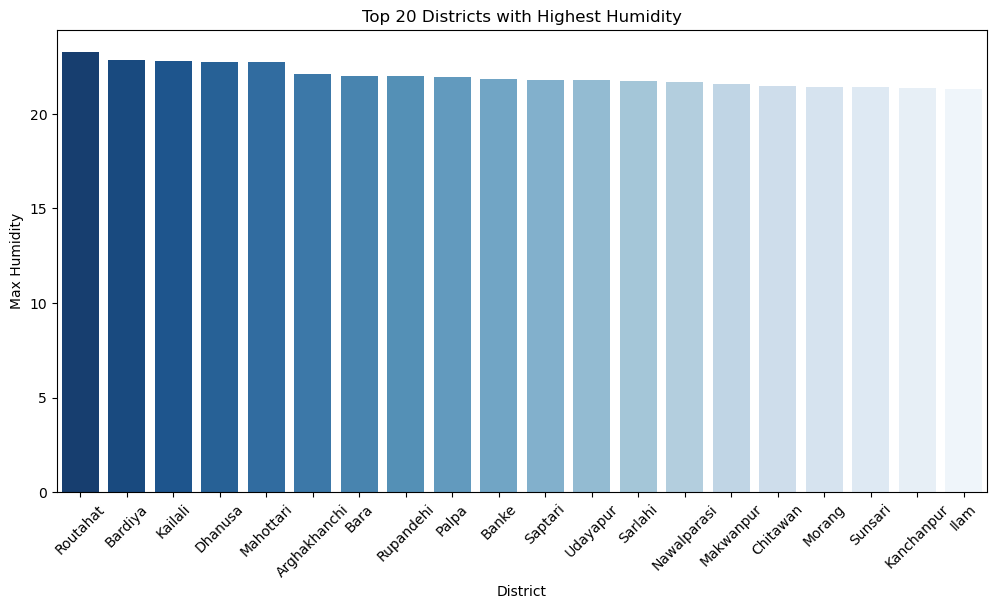

In [5]:
#Barplot of the top 20 districts by maximum temperature
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_humidity_districts.index, y=top_humidity_districts.values, palette="Blues_r")

# Labels
plt.xlabel("District")
plt.ylabel("Max Humidity")
plt.title("Top 20 Districts with Highest Humidity")
plt.xticks(rotation=45)

plt.show()

In [7]:
print("Districts with lowest himidity can be selected")
lowest_humidity_district = daily_df.groupby('District')['Humidity_2m'].min().sort_values(ascending = True).head(20)
lowest_humidity_district

Districts with lowest himidity can be selected


District
Humla          0.27
Solukhumbu     0.37
Mugu           0.43
Dolpa          0.55
Bajang         0.64
Rasuwa         0.64
Mustang        0.67
Manang         0.67
Dolkha         0.70
Darchula       0.73
Baitadi        0.73
Gorkha         0.80
Bhaktapur      0.83
Kabhre         0.83
Chitawan       0.85
Lamjung        0.87
Tanahun        0.87
Dhanusa        0.87
Mahottari      0.87
Nawalparasi    0.88
Name: Humidity_2m, dtype: float64

C:\Users\Karun Bhandari\AppData\Local\Temp\ipykernel_2724\1019741544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lowest_humidity_district.index, y=lowest_humidity_district.values, palette='magma')


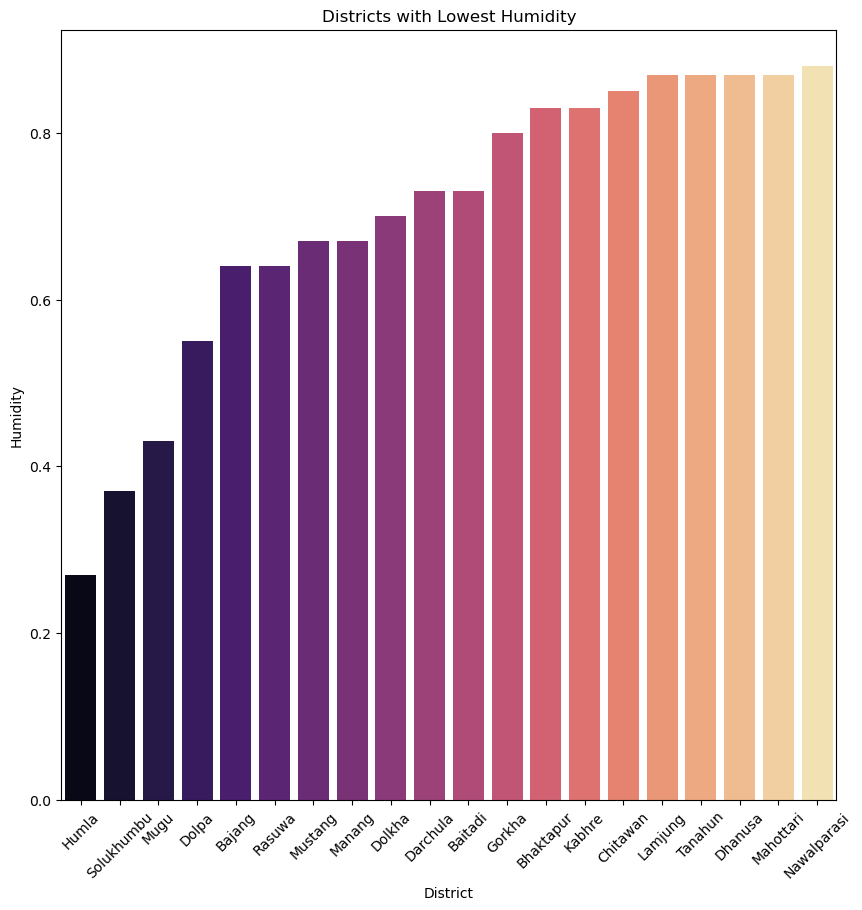

In [ ]:
#Barplot for bottom 20 districts with lowest humidity
plt.figure(figsize=(10,10))
sns.barplot(x=lowest_humidity_district.index, y=lowest_humidity_district.values, palette='magma')  
plt.xlabel("District")
plt.ylabel("Humidity")
plt.title("Districts with Lowest Humidity")
plt.xticks(rotation=45)
plt.show()

In [8]:
df = pd.read_csv(r"../Weather_&_Climate_Data/Processed Datas/5yeargrouped.csv")
df['DATE'] = pd.to_datetime(df['Interval_Start'], format = "mixed", dayfirst = False)

In [10]:
#1. Data Overview
print("Shape of data:", df.shape)
print("Columns:", df.columns.tolist())
print(df.describe())

Shape of data: (620, 25)
Columns: ['District', 'Interval_Start', 'Latitude', 'Longitude', 'Precip', 'Pressure', 'Humidity_2m', 'RH_2m', 'Temp_2m', 'WetBulbTemp_2m', 'MaxTemp_2m', 'MinTemp_2m', 'TempRange_2m', 'EarthSkinTemp', 'WindSpeed_10m', 'MaxWindSpeed_10m', 'MinWindSpeed_10m', 'WindSpeedRange_10m', 'WindSpeed_50m', 'MaxWindSpeed_50m', 'MinWindSpeed_50m', 'WindSpeedRange_50m', 'Year', 'Month', 'DATE']
         Latitude   Longitude      Precip    Pressure  Humidity_2m  \
count  620.000000  620.000000  620.000000  620.000000   620.000000   
mean    27.959677   84.277419    2.469537   82.905522     8.530251   
min     26.500000   80.200000    0.442356   56.080548     3.560300   
25%     27.300000   82.400000    1.760374   77.651867     7.368192   
50%     27.950000   84.300000    2.333945   83.878851     8.554693   
75%     28.500000   85.900000    3.091515   92.777980    10.042779   
max     30.000000   87.900000    5.479974   98.996499    12.744017   
std      0.883973    2.183091  

In [ ]:
# #plot the districts with lowest and highest temperature
# higher_temperature_district = df.groupby("District")["MaxTemp_2m"].max().sort_values(ascending=False).head(10)
# for dist in higher_temperature_district:
#     fig, ax = plt.subplot(5,2, figsize = (5,2.7))
#     ax, plot()

# higher_temperature_district

33.26070496083551
32.628831592689295
32.628831592689295
31.46466710182768
31.06221279373368
30.639843342036556
30.562983028720627
30.5623955613577
30.5623955613577
30.226677545691903


District
Routahat     33.260705
Dhanusa      32.628832
Mahottari    32.628832
Bardiya      31.464667
Bara         31.062213
Sarlahi      30.639843
Kailali      30.562983
Udayapur     30.562396
Saptari      30.562396
Makwanpur    30.226678
Name: MaxTemp_2m, dtype: float64

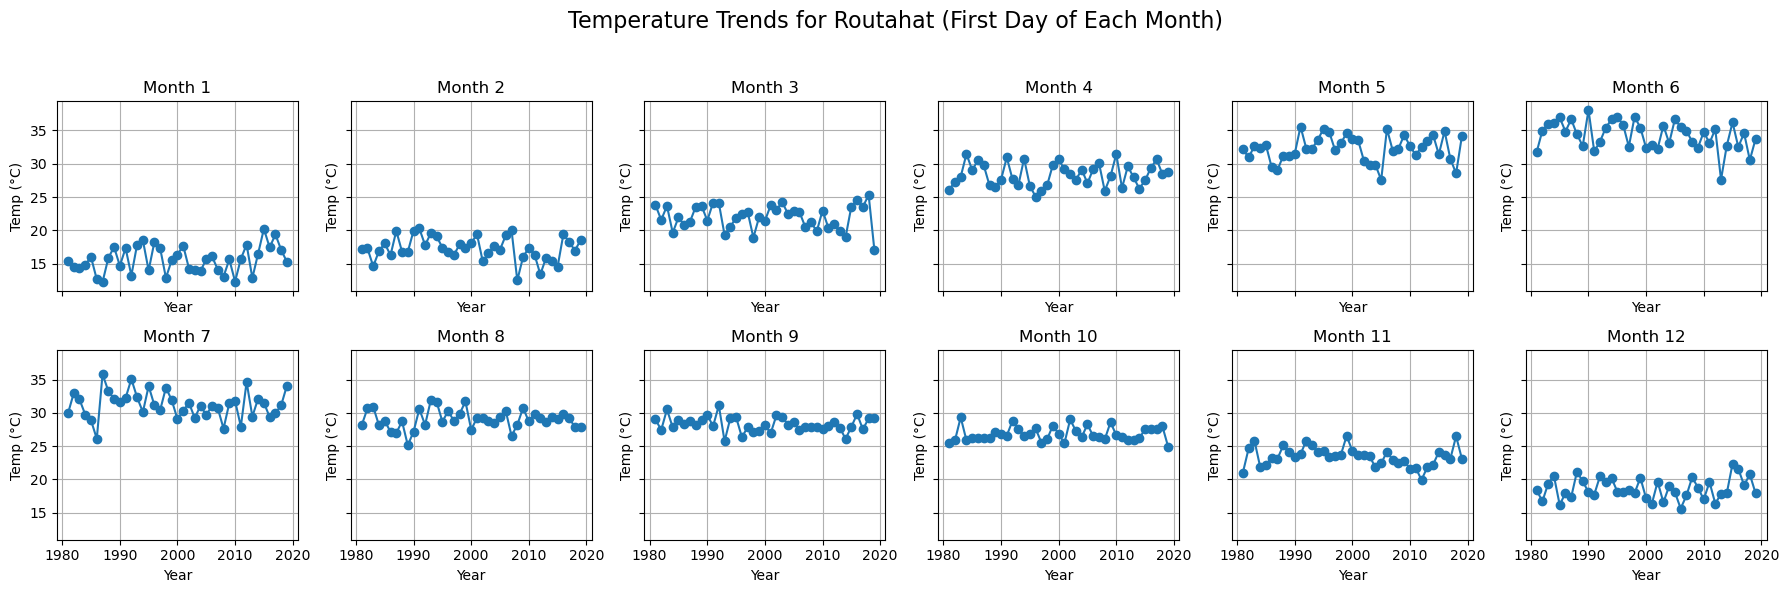

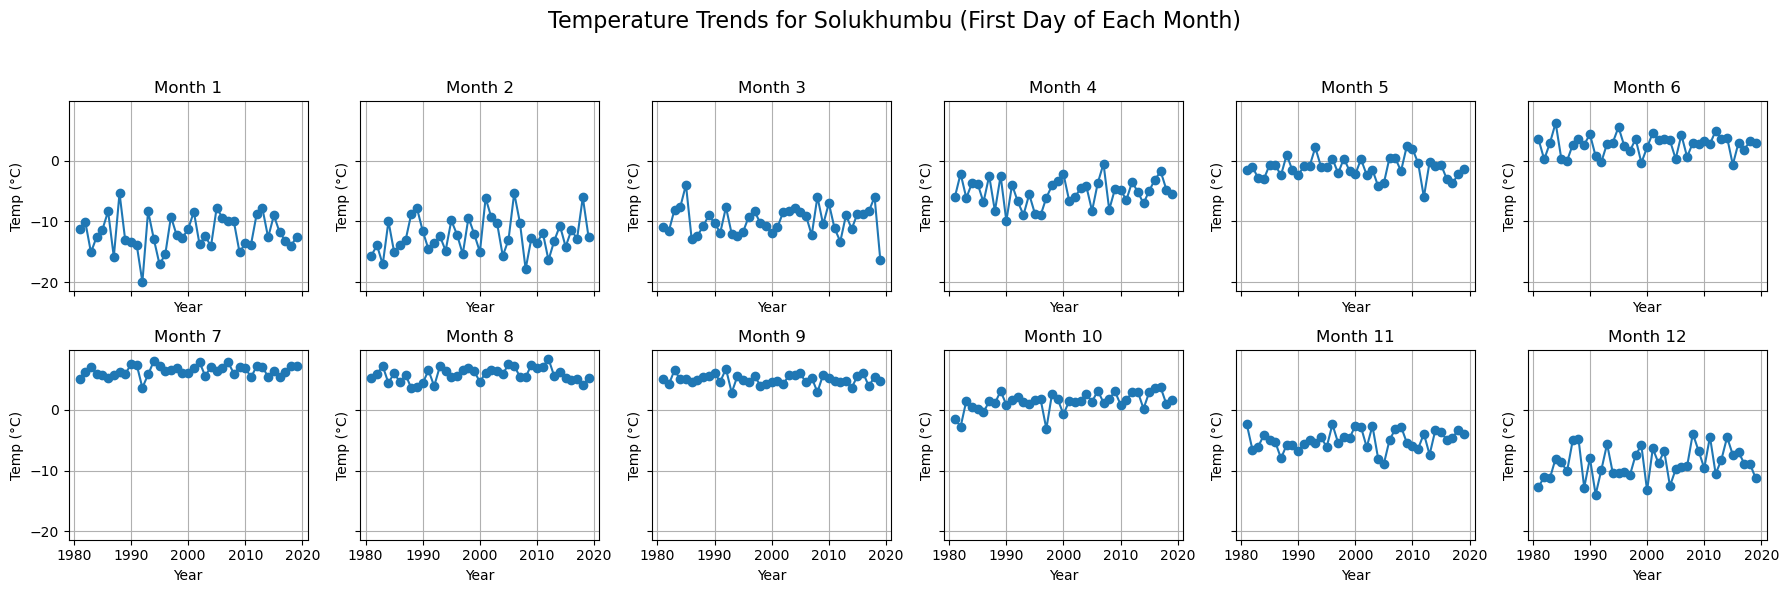

In [19]:
# Convert 'Date' to datetime
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

# Keep only first day of each month (even if not exactly '01')
df_first_day = daily_df[daily_df['Date'].dt.is_month_start].copy()

# Extract Year and Month safely
df_first_day.loc[:, 'Year'] = df_first_day['Date'].dt.year
df_first_day.loc[:, 'Month'] = df_first_day['Date'].dt.month

# Check your actual column names here if needed
# print(df_first_day.columns)

districts = ['Routahat', 'Solukhumbu']

for district in districts:
    fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharex=True, sharey=True)
    fig.suptitle(f'Temperature Trends for {district} (First Day of Each Month)', fontsize=16)

    for month in range(1, 13):
        ax = axes[(month - 1) // 6, (month - 1) % 6]
        
        # Safely filter district and month
        month_data = df_first_day[
            (df_first_day['District'] == district) &
            (df_first_day['Month'] == month)
        ]

        # Skip empty data
        if not month_data.empty:
            ax.plot(month_data['Year'], month_data['Temp_2m'], marker='o', linestyle='-')
        
        ax.set_title(f'Month {month}')
        ax.set_xlabel('Year')
        ax.set_ylabel('Temp (°C)')
        ax.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

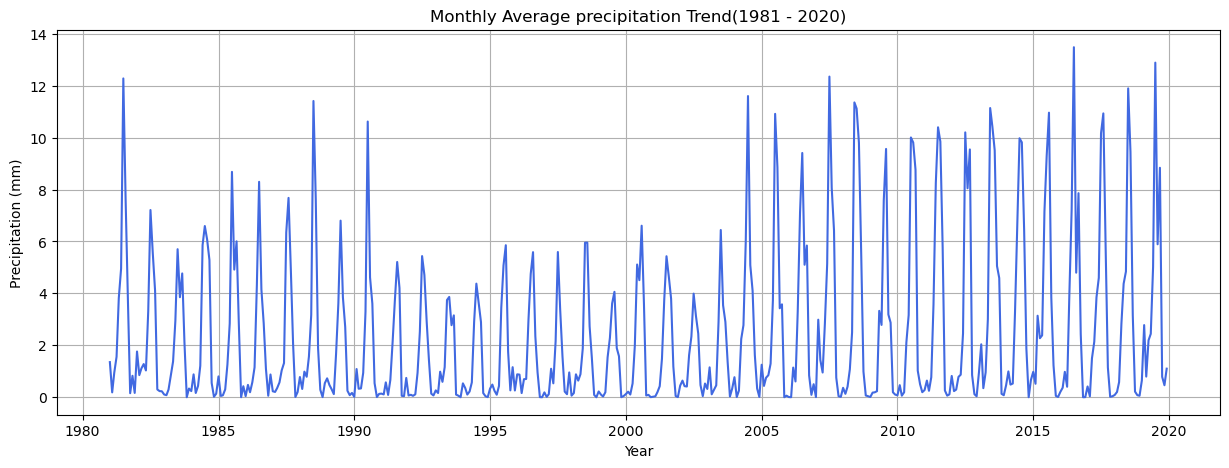

In [21]:
# 3. Precipitation trend over time
monthly_precip = daily_df.groupby(daily_df['Date'].dt.to_period('M'))['Precip'].mean()
monthly_precip.index = monthly_precip.index.to_timestamp()

plt.figure(figsize =(15,5))
plt.plot(monthly_precip.index, monthly_precip.values, color = 'royalblue')
plt.title('Monthly Average precipitation Trend(1981 - 2020)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.show()


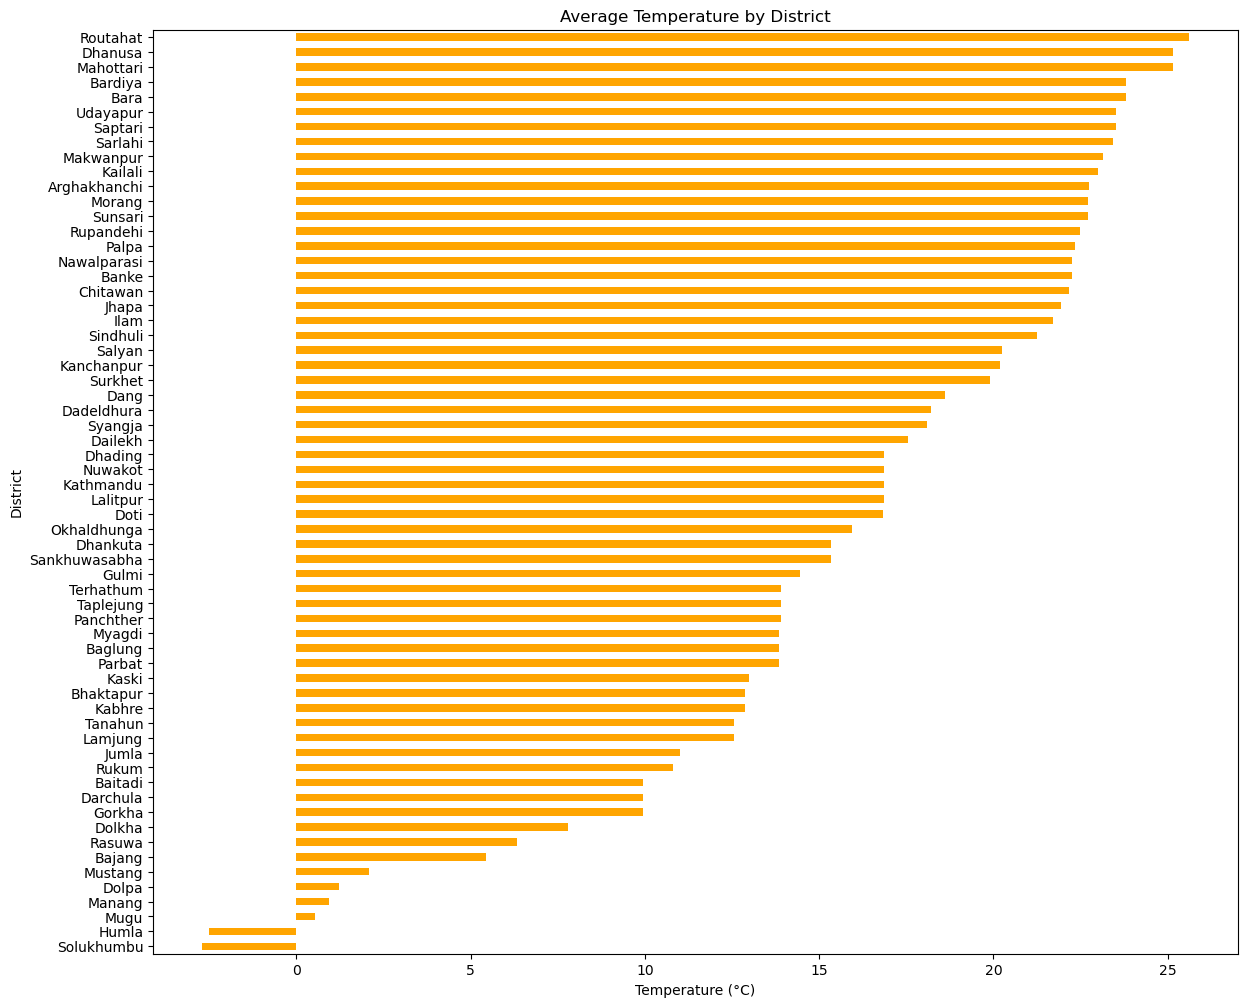

In [22]:
# 4. District-Wise Average Temperature
district_avg_temp = daily_df.groupby('District')['Temp_2m'].mean().sort_values()

plt.figure(figsize=(14,12))
district_avg_temp.plot(kind='barh', color='orange')
plt.title('Average Temperature by District')
plt.xlabel('Temperature (°C)')
plt.show()

In [24]:
# 5. Extreme Weather Detection
#Top 5% highest temperatures
high_temp_days = daily_df[daily_df['Temp_2m'] > daily_df['Temp_2m'].quantile(0.95)]

#high precipitation
high_precip_days = daily_df[daily_df['Precip'] > daily_df['Precip'].quantile(0.95)]

print("High Temp Events:", high_temp_days.shape[0])
print("High Precipitation Events:", high_precip_days.shape[0])

High Temp Events: 43946
High Precipitation Events: 44155


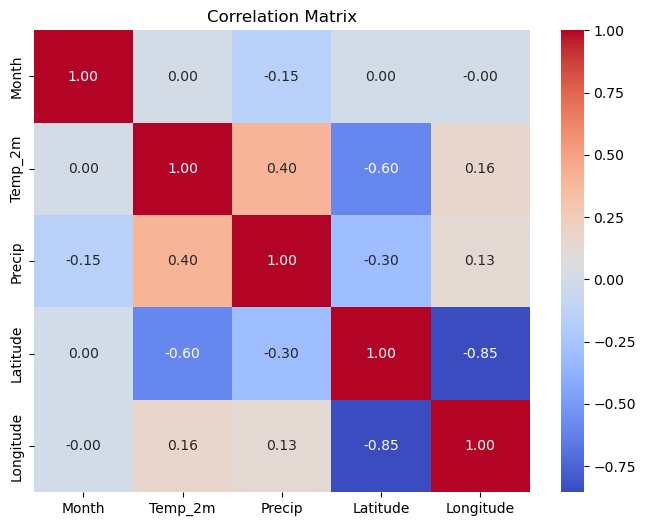

In [26]:
#6. Correlation Analysis
corr = df[['Month','Temp_2m', 'Precip', 'Latitude', 'Longitude']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
# 7. Geospatial Mapping Preparation
district_geo = df.groupby('DISTRICT').agg({
    'LAT':'mean',
    'LON':'mean',
    'T2M':'mean',
    'PRECTOT':'mean'
}).reset_index()

print(district_geo.head())

# 8. Save EDA Summary
district_geo.to_csv('X:/AI DataScience projects/Assignment 8/capstone-project-KarunBhandari/Weather & Climate Data/Processed Datas/DAILYclimateEda_cleaned.csv', index=False)

print("✅ EDA Completed Successfully!")

       DISTRICT   LAT   LON        T2M    PRECTOT
0  Arghakhanchi  27.9  83.2  22.706218  85.570299
1       Baglung  28.3  83.6  13.809338  77.656197
2       Baitadi  29.5  80.5   9.918910  45.520299
3        Bajang  29.6  81.2   5.407607  37.824765
4         Banke  28.1  81.7  22.477863  80.975919
✅ EDA Completed Successfully!


In [27]:
district_long = daily_df.groupby('District')[['Longitude','Latitude']].mean()
district_long=district_long.reset_index()
district_temp = daily_df.groupby('District')[['MaxTemp_2m']].max()

district_temp = district_temp.reset_index()
district_temp_map = pd.merge(district_long,district_temp,on='District')

In [28]:
district_humidity = daily_df.groupby('District')['Humidity_2m'].max()
district_humidity = district_humidity.reset_index()
district_map = pd.merge(district_temp_map,district_humidity,on="District")


In [32]:
# Create Map Centered at a Location
m = folium.Map(location=[27.7172, 85.3240], zoom_start=5)

# Add Markers
for index, row in district_map.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=f"district name {row['District']}<br> temperature{row['MaxTemp_2m']}<br> high humidity{row['Humidity_2m']}").add_to(m)
    
m